# Experiment Outputs Dashboard

This notebook discovers experiment outputs and plots each artifact type in separate sections for clean comparison across runs.

In [1]:
from __future__ import annotations

import json
from datetime import datetime
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

In [2]:
KNOWN_ARTIFACTS = {
    "assignments.parquet",
    "per_document_utility.parquet",
    "pt_experiment.csv",
    "summary.json",
    "memory_summary.json",
    "full_run.parquet",
    "optimized_run.parquet",
    "profile_catalog.csv",
    "sampled_score_pairs.parquet",
}

BASE_OUTPUT_DIR = (Path.cwd().parent / "matryoshka_optimization_codebase" / "outputs").resolve()
EXPORT_ROOT = (Path.cwd() / "exports").resolve()

print("Base outputs dir:", BASE_OUTPUT_DIR)
print("Export root:", EXPORT_ROOT)

Base outputs dir: /home/franchini/Master-Thesis/matryoshka_optimization_codebase/outputs
Export root: /home/franchini/Master-Thesis/analysis_viz/exports


In [ ]:
def _is_excluded_path(path: Path) -> bool:
    parts = {p.lower() for p in path.parts}
    if "models" in parts or "side_quests" in parts:
        print(f"Excluding path (contains 'models' or 'side_quests'): {path}")
        return True
    return False


def _safe_read(path: Path):
    suffix = path.suffix.lower()
    try:
        if suffix == ".parquet":
            return pd.read_parquet(path), None
        if suffix == ".csv":
            return pd.read_csv(path), None
        if suffix == ".json":
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f), None
        return None, f"Unsupported extension: {suffix}"
    except Exception as exc:
        return None, str(exc)


def infer_experiment_type(artifact_names: set[str]) -> str:
    if "assignments.parquet" in artifact_names or "per_document_utility.parquet" in artifact_names:
        return "matryoshka_run"
    if "pt_experiment.csv" in artifact_names and "summary.json" not in artifact_names:
        return "side_quest_benchmark"
    return "generic_experiment"


def discover_runs(base_output_dir: Path) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    if not base_output_dir.exists():
        return pd.DataFrame(columns=["run_name", "run_path", "experiment_type", "artifact_count", "artifacts"])

    for run_dir in sorted(p for p in base_output_dir.rglob("*") if p.is_dir()):
        if _is_excluded_path(run_dir):
            continue

        artifact_paths = [p for p in run_dir.iterdir() if p.is_file() and p.name in KNOWN_ARTIFACTS]
        if not artifact_paths:
            continue

        artifact_names = {p.name for p in artifact_paths}
        rows.append(
            {
                "run_name": run_dir.name,
                "run_path": str(run_dir),
                "experiment_type": infer_experiment_type(artifact_names),
                "artifact_count": len(artifact_names),
                "artifacts": sorted(artifact_names),
            }
        )

    return pd.DataFrame(rows).sort_values(["experiment_type", "run_name"]).reset_index(drop=True) if rows else pd.DataFrame(
        columns=["run_name", "run_path", "experiment_type", "artifact_count", "artifacts"]
    )


def load_run_artifacts(run_path: str | Path) -> dict[str, Any]:
    run_path = Path(run_path)
    bundle: dict[str, Any] = {
        "run_name": run_path.name,
        "run_path": run_path,
        "tables": {},
        "json": {},
        "errors": {},
        "schema": {},
    }

    for artifact in KNOWN_ARTIFACTS:
        artifact_path = run_path / artifact
        if not artifact_path.exists():
            continue
        data, err = _safe_read(artifact_path)
        if err:
            bundle["errors"][artifact] = err
            continue

        if isinstance(data, pd.DataFrame):
            bundle["tables"][artifact] = data
            bundle["schema"][artifact] = {
                "rows": int(len(data)),
                "columns": list(data.columns),
            }
        elif isinstance(data, dict):
            bundle["json"][artifact] = data
            bundle["schema"][artifact] = {
                "keys": sorted(list(data.keys())),
            }

    return bundle


def build_manifest_with_schema(manifest: pd.DataFrame) -> pd.DataFrame:
    if manifest.empty:
        return manifest

    rows = []
    for _, row in manifest.iterrows():
        bundle = load_run_artifacts(row["run_path"])
        table_row_counts = {
            name: meta.get("rows")
            for name, meta in bundle["schema"].items()
            if "rows" in meta
        }
        key_columns = {
            name: meta.get("columns", [])[:8]
            for name, meta in bundle["schema"].items()
            if "columns" in meta
        }
        rows.append(
            {
                **row.to_dict(),
                "table_row_counts": table_row_counts,
                "key_columns": key_columns,
                "load_errors": bundle["errors"],
            }
        )
    return pd.DataFrame(rows)


def _first_existing_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    return None

## Discover Experiment Runs

This cell discovers run folders under `outputs/`, excludes `models` paths, and builds the run manifest.

In [4]:
manifest = discover_runs(BASE_OUTPUT_DIR)
if manifest.empty:
    print("No experiment outputs discovered yet. Add run folders under:")
    print(BASE_OUTPUT_DIR)
else:
    display(manifest)

,run_name,run_path,experiment_type,artifact_count,artifacts
0,modernbert_finetuned_msmarco_logrel_bm25,/home/franchini/Master-Thesis/matryoshka_optim...,matryoshka_run,9,"[assignments.parquet, full_run.parquet, memory..."
1,starbucks_msmarco_logrel_bm25,/home/franchini/Master-Thesis/matryoshka_optim...,matryoshka_run,9,"[assignments.parquet, full_run.parquet, memory..."


## Schema Profiling

This cell loads discovered artifacts safely and summarizes row counts, key columns, and loading errors per run.

In [5]:
manifest_profiled = build_manifest_with_schema(manifest)
if not manifest_profiled.empty:
    display(manifest_profiled[["run_name", "experiment_type", "artifact_count", "table_row_counts", "key_columns", "load_errors"]])

,run_name,experiment_type,artifact_count,table_row_counts,key_columns,load_errors
0,modernbert_finetuned_msmarco_logrel_bm25,matryoshka_run,9,"{'assignments.parquet': 8841823, 'per_document...","{'assignments.parquet': ['docno', 'profile', '...",{}
1,starbucks_msmarco_logrel_bm25,matryoshka_run,9,"{'assignments.parquet': 8841823, 'per_document...","{'assignments.parquet': ['docno', 'profile', '...",{}


## Load All Run Bundles

This cell prepares a bundle per run so each subsequent section can compare one artifact type across all runs.

In [6]:
run_bundles = []
if manifest.empty:
    print("No run bundles loaded because discovery found no runs.")
else:
    for _, row in manifest.iterrows():
        run_bundles.append(load_run_artifacts(row["run_path"]))
    print(f"Loaded {len(run_bundles)} run bundles.")

Loaded 2 run bundles.


## Assignments Comparison (`assignments.parquet`)

Plots docs-per-profile (bar chart) and assigned cost distributions for every run that has `assignments.parquet`.

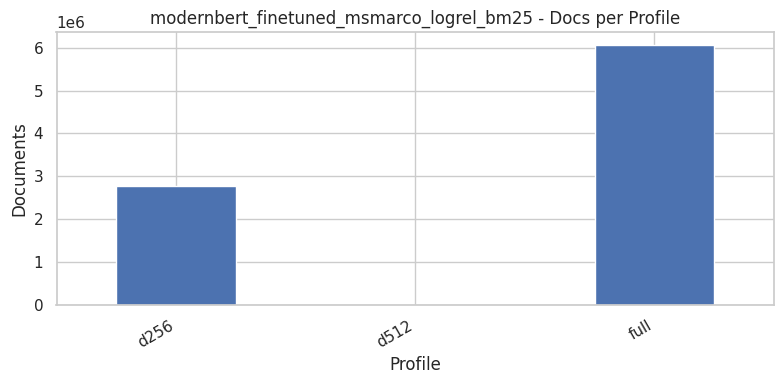

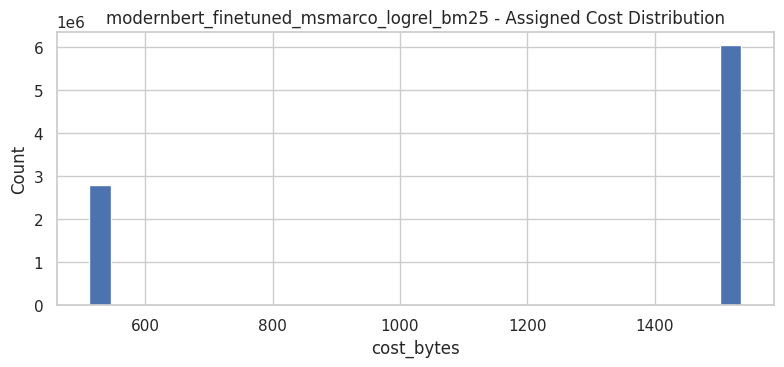

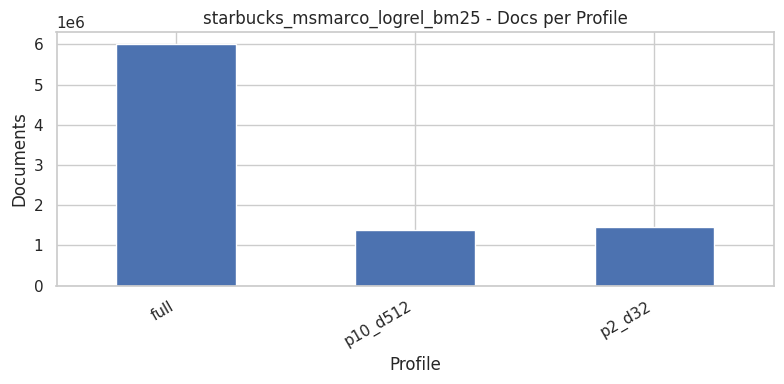

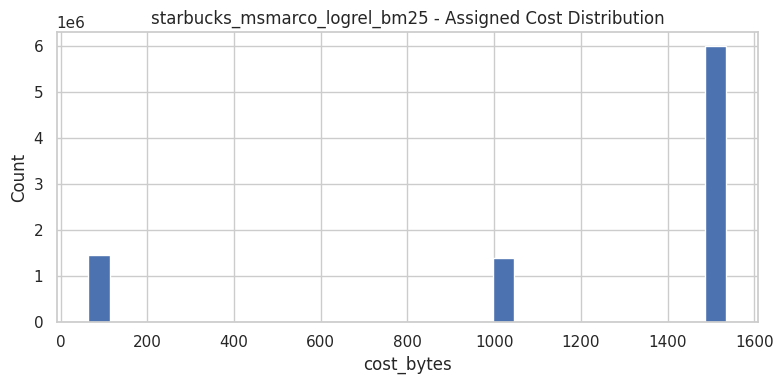

In [7]:
if not run_bundles:
    print("No bundles available.")
else:
    plotted = 0
    for b in run_bundles:
        df = b["tables"].get("assignments.parquet")
        if df is None or df.empty:
            continue

        profile_col = _first_existing_col(df, ["profile", "profile_name", "assigned_profile", "name"])
        cost_col = _first_existing_col(df, ["cost_bytes", "cost"])

        if profile_col:
            counts = df[profile_col].astype(str).value_counts().sort_index()
            fig, ax = plt.subplots(figsize=(8, 4))
            counts.plot(kind="bar", ax=ax)
            ax.set_title(f"{b['run_name']} - Docs per Profile")
            ax.set_xlabel("Profile")
            ax.set_ylabel("Documents")
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plt.show()
            plotted += 1

        if cost_col and pd.api.types.is_numeric_dtype(df[cost_col]):
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.hist(df[cost_col].dropna(), bins=30)
            ax.set_title(f"{b['run_name']} - Assigned Cost Distribution")
            ax.set_xlabel(cost_col)
            ax.set_ylabel("Count")
            plt.tight_layout()
            plt.show()
            plotted += 1

    if plotted == 0:
        print("No plottable assignments tables found.")

## Utility Comparison (`per_document_utility.parquet`)

Plots utility distributions and utility-by-profile comparisons for each run with utility tables.

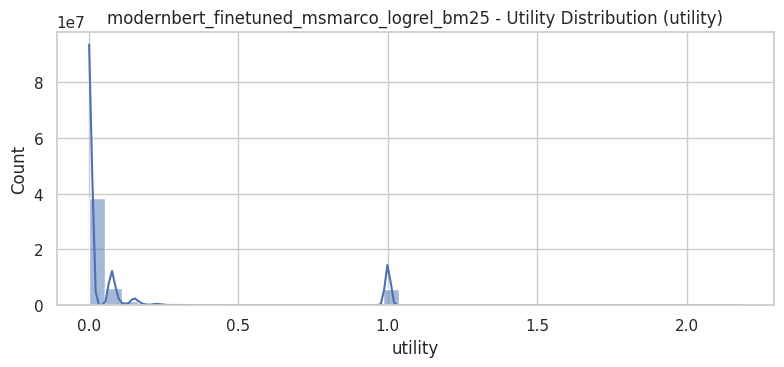

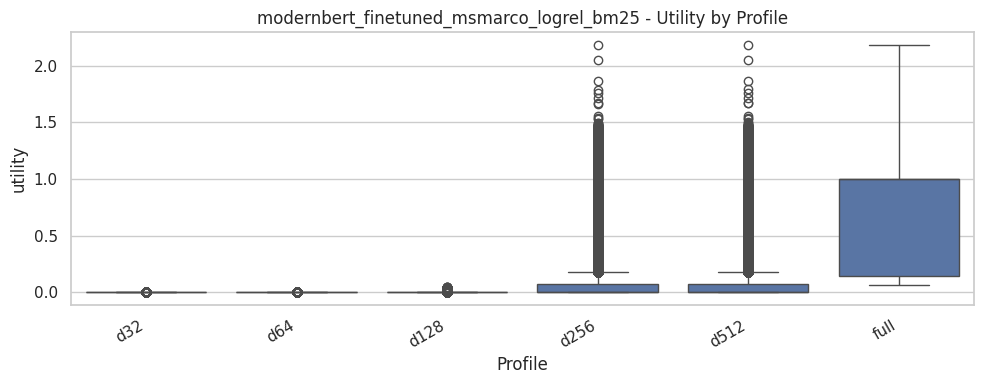

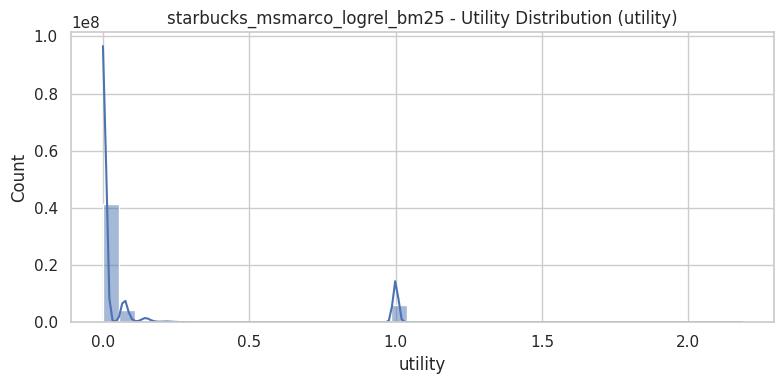

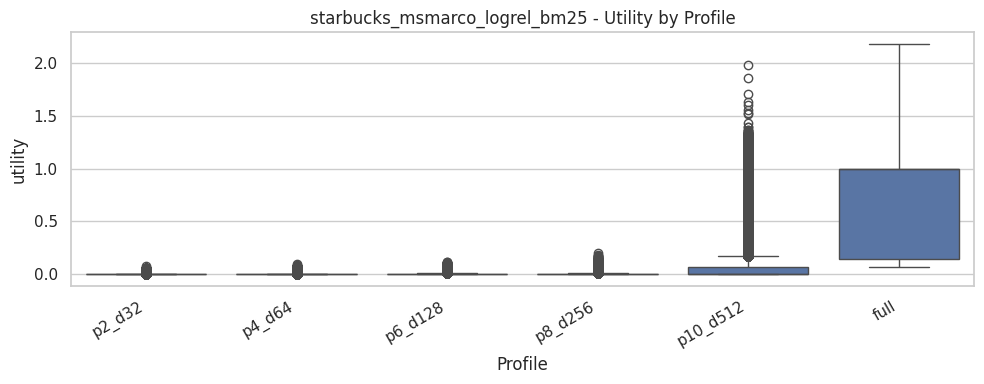

In [8]:
if not run_bundles:
    print("No bundles available.")
else:
    plotted = 0
    for b in run_bundles:
        df = b["tables"].get("per_document_utility.parquet")
        if df is None or df.empty:
            continue

        numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        utility_col = _first_existing_col(df, ["utility", "mean_utility", "u", "score"])
        if utility_col is None and numeric_cols:
            utility_col = numeric_cols[0]

        profile_col = _first_existing_col(df, ["profile", "profile_name", "candidate_profile"])

        if utility_col:
            fig, ax = plt.subplots(figsize=(8, 4))
            series = df[utility_col].dropna()
            if sns is not None:
                sns.histplot(series, bins=40, kde=True, ax=ax)
            else:
                ax.hist(series, bins=40)
            ax.set_title(f"{b['run_name']} - Utility Distribution ({utility_col})")
            ax.set_xlabel(utility_col)
            ax.set_ylabel("Count")
            plt.tight_layout()
            plt.show()
            plotted += 1

        if utility_col and profile_col and df[profile_col].nunique() > 1:
            fig, ax = plt.subplots(figsize=(10, 4))
            if sns is not None:
                sns.boxplot(data=df, x=profile_col, y=utility_col, ax=ax)
            else:
                df.boxplot(column=utility_col, by=profile_col, ax=ax)
                plt.suptitle("")
            ax.set_title(f"{b['run_name']} - Utility by Profile")
            ax.set_xlabel("Profile")
            ax.set_ylabel(utility_col)
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plt.show()
            plotted += 1

    if plotted == 0:
        print("No plottable per_document_utility tables found.")

## Evaluation Comparison (`pt_experiment.csv`)

Plots evaluation metrics and metric deltas (when both baseline and optimized rows exist) for each run.

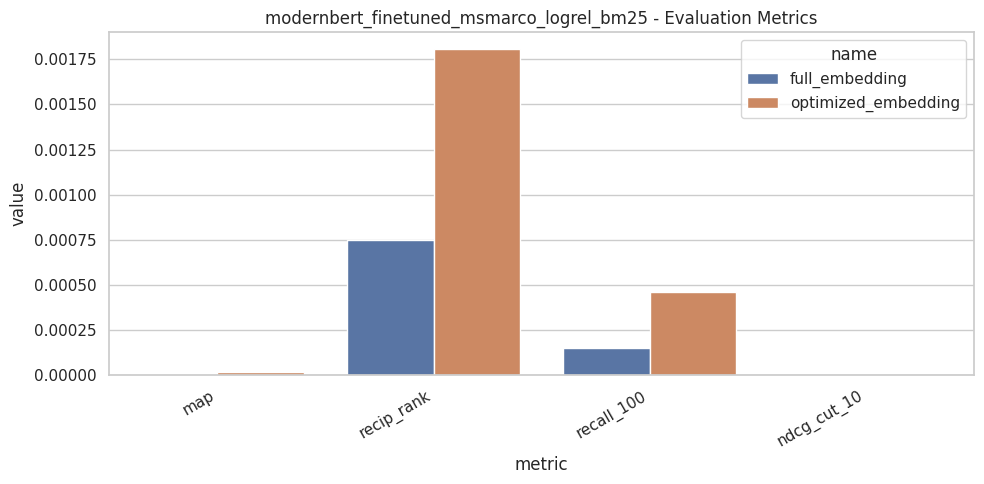

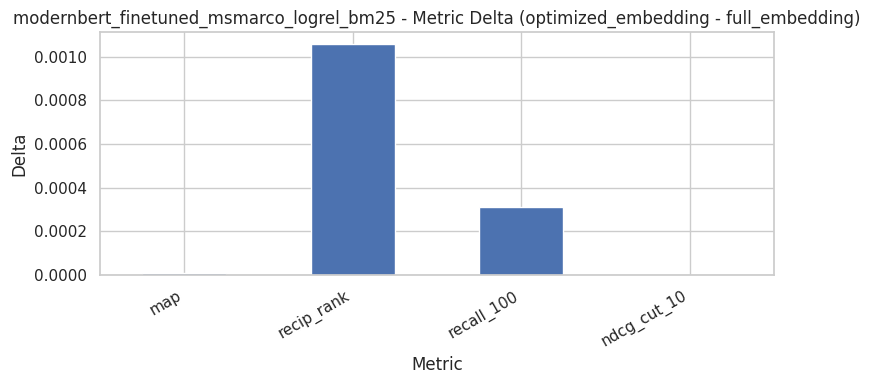

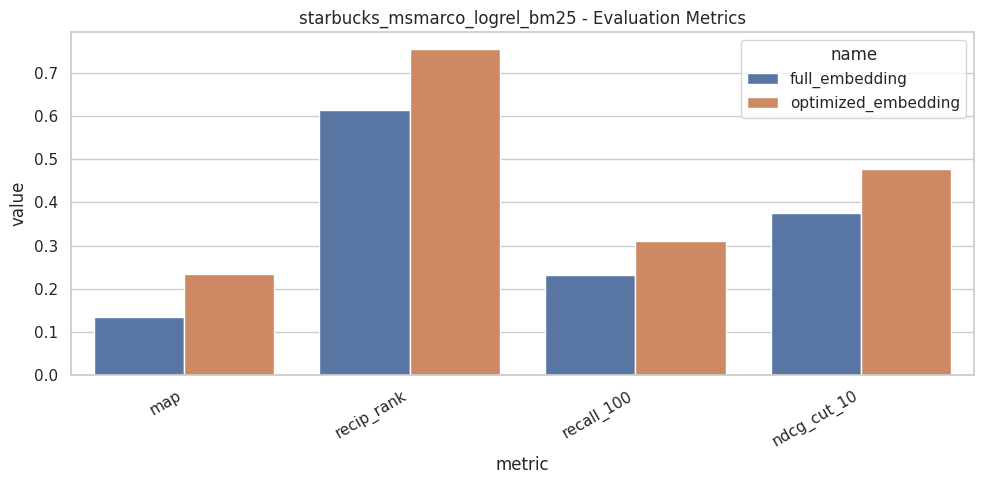

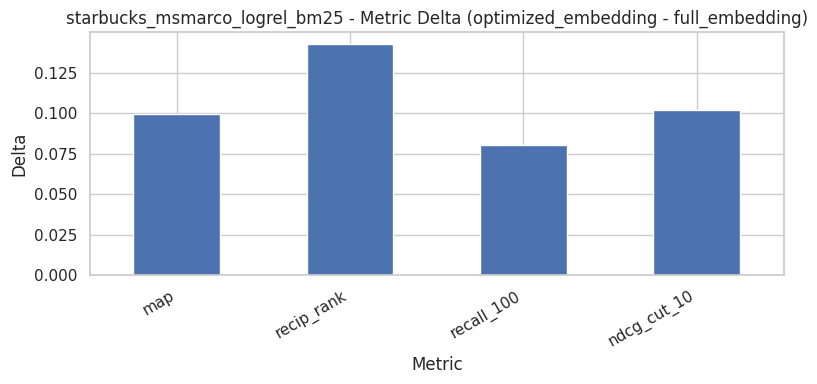

In [9]:
if not run_bundles:
    print("No bundles available.")
else:
    plotted = 0
    for b in run_bundles:
        df = b["tables"].get("pt_experiment.csv")
        if df is None or df.empty:
            continue

        run_col = _first_existing_col(df, ["name", "system", "run", "model"])
        metric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

        if run_col and metric_cols:
            melted = df.melt(id_vars=[run_col], value_vars=metric_cols, var_name="metric", value_name="value")
            fig, ax = plt.subplots(figsize=(10, 5))
            if sns is not None:
                sns.barplot(data=melted, x="metric", y="value", hue=run_col, ax=ax)
            else:
                for label, grp in melted.groupby(run_col):
                    ax.plot(grp["metric"], grp["value"], marker="o", label=label)
                ax.legend()
            ax.set_title(f"{b['run_name']} - Evaluation Metrics")
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plt.show()
            plotted += 1

            if df[run_col].nunique() >= 2:
                base = df.iloc[0]
                comp = df.iloc[1]
                deltas = pd.Series({m: comp[m] - base[m] for m in metric_cols}, name="delta")
                fig, ax = plt.subplots(figsize=(8, 4))
                deltas.plot(kind="bar", ax=ax)
                ax.set_title(f"{b['run_name']} - Metric Delta ({comp[run_col]} - {base[run_col]})")
                ax.set_xlabel("Metric")
                ax.set_ylabel("Delta")
                plt.xticks(rotation=30, ha="right")
                plt.tight_layout()
                plt.show()
                plotted += 1

    if plotted == 0:
        print("No plottable pt_experiment.csv tables found.")

## Summary and Memory Comparison (`summary.json`, `memory_summary.json`)

Displays compact KPI tables and memory usage bars per run using summary JSON artifacts.

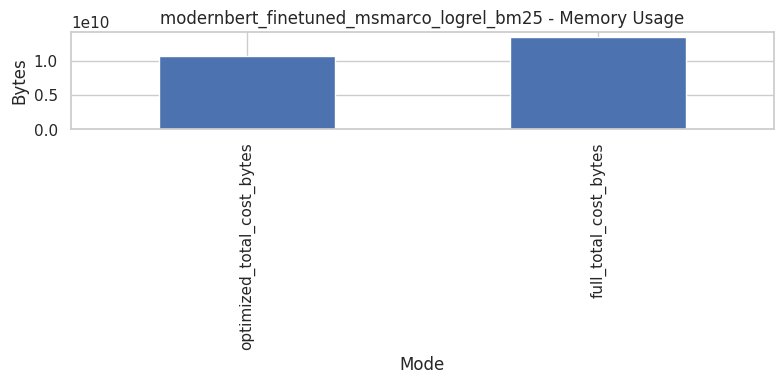

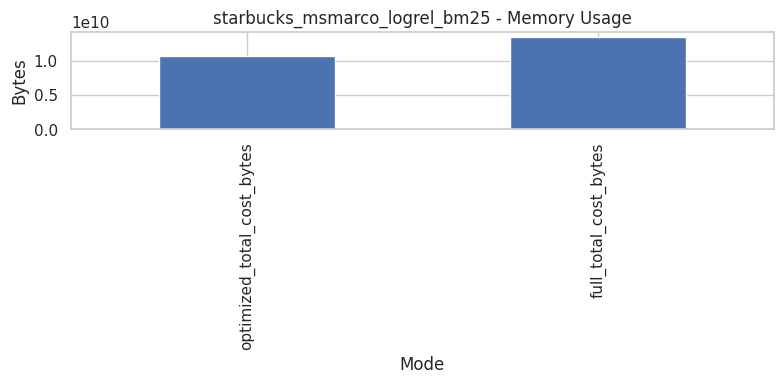

,run_name,lambda_star,optimized_total_utility,num_docs,num_queries,budget_bytes,optimized_total_cost_bytes,full_total_cost_bytes
0,modernbert_finetuned_msmarco_logrel_bm25,5.368864e-07,6.289588e+06,8841823,200,10737418240,10730607104,13581040128
1,starbucks_msmarco_logrel_bm25,7.392763e-05,6.169939e+06,8841823,200,10737418240,10731924416,13581040128


In [10]:
if not run_bundles:
    print("No bundles available.")
else:
    plotted = 0
    kpi_rows = []
    for b in run_bundles:
        summary = b["json"].get("summary.json", {})
        memory = b["json"].get("memory_summary.json", {})
        if not summary and not memory:
            continue

        row = {
            "run_name": b["run_name"],
            "lambda_star": summary.get("lambda_star"),
            "optimized_total_utility": summary.get("optimized_total_utility"),
            "num_docs": summary.get("num_docs"),
            "num_queries": summary.get("num_queries"),
            "budget_bytes": memory.get("budget_bytes"),
            "optimized_total_cost_bytes": memory.get("optimized_total_cost_bytes"),
            "full_total_cost_bytes": memory.get("full_total_cost_bytes"),
        }
        kpi_rows.append(row)

        if memory.get("optimized_total_cost_bytes") is not None and memory.get("full_total_cost_bytes") is not None:
            s = pd.Series({
                "optimized_total_cost_bytes": memory["optimized_total_cost_bytes"],
                "full_total_cost_bytes": memory["full_total_cost_bytes"],
            })
            fig, ax = plt.subplots(figsize=(8, 4))
            s.plot(kind="bar", ax=ax)
            ax.set_title(f"{b['run_name']} - Memory Usage")
            ax.set_xlabel("Mode")
            ax.set_ylabel("Bytes")
            plt.tight_layout()
            plt.show()
            plotted += 1

    if kpi_rows:
        display(pd.DataFrame(kpi_rows).sort_values("run_name").reset_index(drop=True))
    if plotted == 0 and not kpi_rows:
        print("No summary/memory JSON data found.")

## Retrieval Runs Comparison (`full_run.parquet`, `optimized_run.parquet`)

Compares score distributions and per-query top-k overlap between full and optimized runs for each experiment.

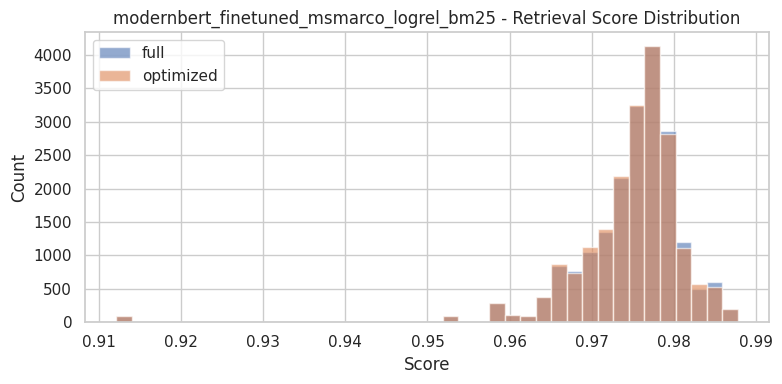

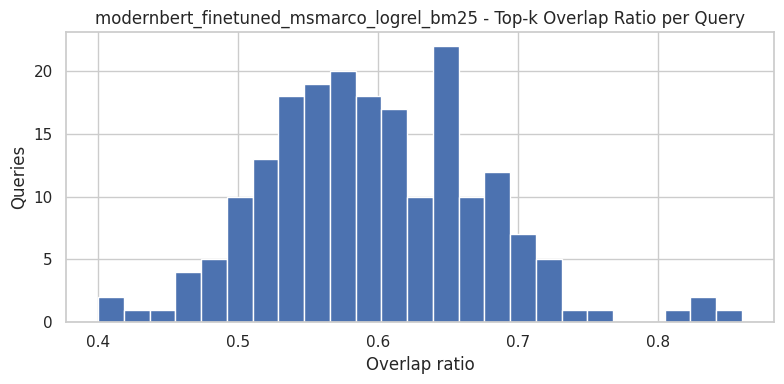

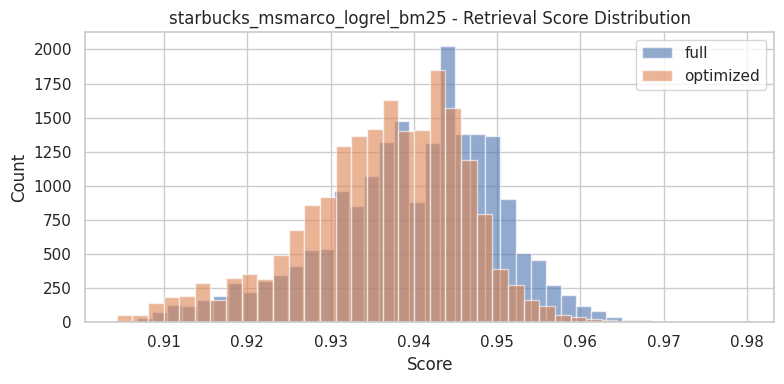

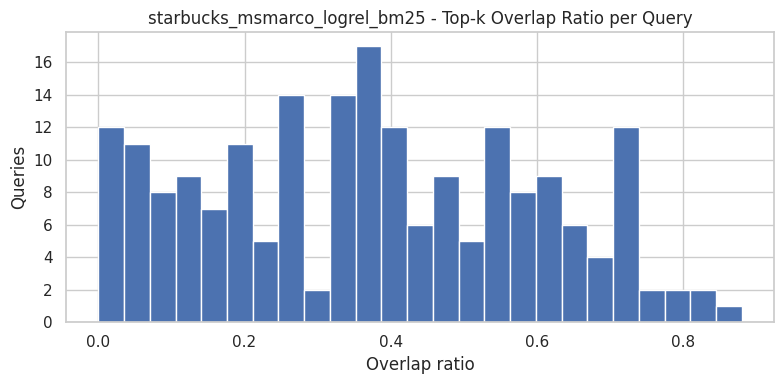

In [11]:
if not run_bundles:
    print("No bundles available.")
else:
    plotted = 0
    for b in run_bundles:
        full_df = b["tables"].get("full_run.parquet")
        opt_df = b["tables"].get("optimized_run.parquet")
        if full_df is None or opt_df is None or full_df.empty or opt_df.empty:
            continue

        full_score_col = _first_existing_col(full_df, ["score", "sim", "similarity"])
        opt_score_col = _first_existing_col(opt_df, ["score", "sim", "similarity"])

        if full_score_col and opt_score_col:
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.hist(full_df[full_score_col].dropna(), bins=40, alpha=0.6, label="full")
            ax.hist(opt_df[opt_score_col].dropna(), bins=40, alpha=0.6, label="optimized")
            ax.set_title(f"{b['run_name']} - Retrieval Score Distribution")
            ax.set_xlabel("Score")
            ax.set_ylabel("Count")
            ax.legend()
            plt.tight_layout()
            plt.show()
            plotted += 1

        qid_col_full = _first_existing_col(full_df, ["qid", "query_id"])
        doc_col_full = _first_existing_col(full_df, ["docno", "doc_id"])
        qid_col_opt = _first_existing_col(opt_df, ["qid", "query_id"])
        doc_col_opt = _first_existing_col(opt_df, ["docno", "doc_id"])

        if qid_col_full and doc_col_full and qid_col_opt and doc_col_opt:
            overlaps = []
            full_groups = full_df.groupby(qid_col_full)[doc_col_full].apply(set)
            opt_groups = opt_df.groupby(qid_col_opt)[doc_col_opt].apply(set)
            common_qids = sorted(set(full_groups.index).intersection(set(opt_groups.index)))
            for qid in common_qids:
                a = full_groups.loc[qid]
                bset = opt_groups.loc[qid]
                denom = max(len(a), 1)
                overlaps.append(len(a.intersection(bset)) / denom)

            if overlaps:
                fig, ax = plt.subplots(figsize=(8, 4))
                ax.hist(overlaps, bins=25)
                ax.set_title(f"{b['run_name']} - Top-k Overlap Ratio per Query")
                ax.set_xlabel("Overlap ratio")
                ax.set_ylabel("Queries")
                plt.tight_layout()
                plt.show()
                plotted += 1

    if plotted == 0:
        print("No full/optimized run pairs found for plotting.")

## Cross-Run Summary Builder

Builds a single comparison table with core KPIs, memory savings, and evaluation metrics across all runs.

In [12]:
def build_cross_run_summary(run_bundles: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for b in run_bundles:
        run_name = b["run_name"]
        summary = b.get("json", {}).get("summary.json", {})
        memory = b.get("json", {}).get("memory_summary.json", {})
        pt_eval = b.get("tables", {}).get("pt_experiment.csv")

        row = {
            "run_name": run_name,
            "lambda_star": summary.get("lambda_star"),
            "optimized_total_utility": summary.get("optimized_total_utility"),
            "num_docs": summary.get("num_docs"),
            "num_queries": summary.get("num_queries"),
            "budget_bytes": memory.get("budget_bytes"),
            "optimized_total_cost_bytes": memory.get("optimized_total_cost_bytes"),
            "full_total_cost_bytes": memory.get("full_total_cost_bytes"),
        }
        if row["optimized_total_cost_bytes"] is not None and row["full_total_cost_bytes"] is not None and row["full_total_cost_bytes"]:
            row["memory_saved_pct"] = 100.0 * (1.0 - (row["optimized_total_cost_bytes"] / row["full_total_cost_bytes"]))
        else:
            row["memory_saved_pct"] = np.nan

        if isinstance(pt_eval, pd.DataFrame) and not pt_eval.empty:
            num_cols = [c for c in pt_eval.columns if pd.api.types.is_numeric_dtype(pt_eval[c])]
            run_col = _first_existing_col(pt_eval, ["name", "run", "system", "model"])
            if run_col and len(pt_eval) >= 2:
                base = pt_eval.iloc[0]
                comp = pt_eval.iloc[1]
                for m in num_cols:
                    row[f"metric_delta__{m}"] = comp[m] - base[m]
                    row[f"metric_opt__{m}"] = comp[m]
                    row[f"metric_base__{m}"] = base[m]
            elif num_cols:
                for m in num_cols:
                    row[f"metric__{m}"] = float(pt_eval[m].mean())

        rows.append(row)

    return pd.DataFrame(rows).sort_values("run_name").reset_index(drop=True) if rows else pd.DataFrame()


cross_summary = build_cross_run_summary(run_bundles)
if cross_summary.empty:
    print("No cross-run summary available yet.")
else:
    display(cross_summary)

,run_name,lambda_star,optimized_total_utility,num_docs,num_queries,budget_bytes,optimized_total_cost_bytes,full_total_cost_bytes,memory_saved_pct,metric_delta__map,metric_opt__map,metric_base__map,metric_delta__recip_rank,metric_opt__recip_rank,metric_base__recip_rank,metric_delta__recall_100,metric_opt__recall_100,metric_base__recall_100,metric_delta__ndcg_cut_10,metric_opt__ndcg_cut_10,metric_base__ndcg_cut_10
0,modernbert_finetuned_msmarco_logrel_bm25,5.368864e-07,6.289588e+06,8841823,200,10737418240,10730607104,13581040128,20.988326,0.00001,0.000015,0.000005,0.001059,0.001809,0.000750,0.000310,0.000461,0.000151,0.000000,0.00000,0.000000
1,starbucks_msmarco_logrel_bm25,7.392763e-05,6.169939e+06,8841823,200,10737418240,10731924416,13581040128,20.978627,0.09970,0.233697,0.133997,0.142739,0.755998,0.613259,0.080132,0.311353,0.231220,0.101756,0.47763,0.375874


## Cross-Run Metric Comparison Plot

Plots grouped bars of optimized evaluation metrics across experiments.

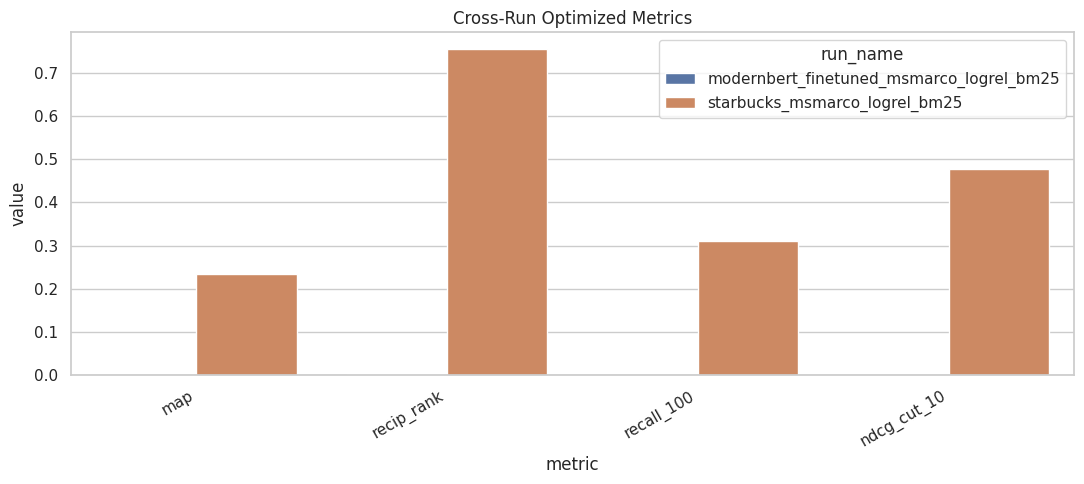

In [13]:
if cross_summary.empty:
    print("No cross-run summary available.")
else:
    metric_opt_cols = [c for c in cross_summary.columns if c.startswith("metric_opt__")]
    if not metric_opt_cols:
        print("No optimized metric columns found.")
    else:
        melted = cross_summary.melt(id_vars=["run_name"], value_vars=metric_opt_cols, var_name="metric", value_name="value")
        melted["metric"] = melted["metric"].str.replace("metric_opt__", "", regex=False)
        fig, ax = plt.subplots(figsize=(11, 5))
        if sns is not None:
            sns.barplot(data=melted, x="metric", y="value", hue="run_name", ax=ax)
        else:
            for run_name, grp in melted.groupby("run_name"):
                ax.plot(grp["metric"], grp["value"], marker="o", label=run_name)
            ax.legend()
        ax.set_title("Cross-Run Optimized Metrics")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

## Cross-Run Tradeoff Scatter

Plots memory savings versus the first available metric delta to visualize quality-memory tradeoffs.

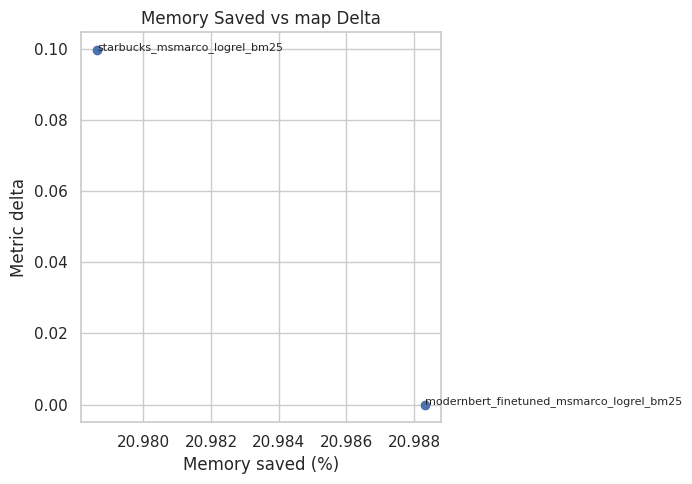

In [14]:
if cross_summary.empty:
    print("No cross-run summary available.")
else:
    metric_delta_cols = [c for c in cross_summary.columns if c.startswith("metric_delta__")]
    if not metric_delta_cols:
        print("No metric delta columns found.")
    else:
        primary_delta = metric_delta_cols[0]
        plot_df = cross_summary.dropna(subset=["memory_saved_pct", primary_delta]).copy()
        if plot_df.empty:
            print("Not enough data for tradeoff scatter.")
        else:
            fig, ax = plt.subplots(figsize=(7, 5))
            ax.scatter(plot_df["memory_saved_pct"], plot_df[primary_delta])
            for _, r in plot_df.iterrows():
                ax.annotate(r["run_name"], (r["memory_saved_pct"], r[primary_delta]), fontsize=8)
            ax.set_title(f"Memory Saved vs {primary_delta.replace('metric_delta__', '')} Delta")
            ax.set_xlabel("Memory saved (%)")
            ax.set_ylabel("Metric delta")
            plt.tight_layout()
            plt.show()

## Cross-Run Ranking Table

Shows runs ranked by the first available optimized metric (or delta metric when optimized metrics are unavailable).

In [15]:
if cross_summary.empty:
    print("No cross-run summary available.")
else:
    metric_opt_cols = [c for c in cross_summary.columns if c.startswith("metric_opt__")]
    metric_delta_cols = [c for c in cross_summary.columns if c.startswith("metric_delta__")]

    ranking_col = None
    if metric_opt_cols:
        ranking_col = metric_opt_cols[0]
    elif metric_delta_cols:
        ranking_col = metric_delta_cols[0]

    if ranking_col is None:
        print("No ranking metric column found.")
    else:
        ranking = cross_summary.sort_values(ranking_col, ascending=False)[["run_name", ranking_col, "memory_saved_pct", "optimized_total_utility"]]
        display(ranking)

,run_name,metric_opt__map,memory_saved_pct,optimized_total_utility
1,starbucks_msmarco_logrel_bm25,0.233697,20.978627,6.169939e+06
0,modernbert_finetuned_msmarco_logrel_bm25,0.000015,20.988326,6.289588e+06


## Export Dashboard Outputs

Exports manifest, cross-run summary, and artifact-specific plots to `analysis_viz/exports/<timestamp>/`.

In [16]:
def export_dashboard_outputs(
    manifest_df: pd.DataFrame,
    cross_summary_df: pd.DataFrame,
    run_bundles_in: list[dict[str, Any]],
    export_root: Path,
) -> Path:
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = export_root / ts
    out_dir.mkdir(parents=True, exist_ok=True)

    manifest_df.to_csv(out_dir / "run_manifest.csv", index=False)
    cross_summary_df.to_csv(out_dir / "cross_run_summary.csv", index=False)

    for bundle in run_bundles_in:
        run_dir = out_dir / bundle["run_name"]
        run_dir.mkdir(parents=True, exist_ok=True)

        assignments = bundle["tables"].get("assignments.parquet")
        if assignments is not None and not assignments.empty:
            profile_col = _first_existing_col(assignments, ["profile", "profile_name", "assigned_profile", "name"])
            if profile_col:
                fig, ax = plt.subplots(figsize=(8, 4))
                assignments[profile_col].astype(str).value_counts().sort_index().plot(kind="bar", ax=ax)
                ax.set_title(f"{bundle['run_name']} - Docs per Profile")
                ax.set_xlabel("Profile")
                ax.set_ylabel("Documents")
                plt.xticks(rotation=30, ha="right")
                plt.tight_layout()
                fig.savefig(run_dir / "assignments_profile_counts.png", dpi=150, bbox_inches="tight")
                plt.close(fig)

        utility = bundle["tables"].get("per_document_utility.parquet")
        if utility is not None and not utility.empty:
            utility_col = _first_existing_col(utility, ["utility", "mean_utility", "u", "score"])
            if utility_col is None:
                num_cols = [c for c in utility.columns if pd.api.types.is_numeric_dtype(utility[c])]
                utility_col = num_cols[0] if num_cols else None
            if utility_col:
                fig, ax = plt.subplots(figsize=(8, 4))
                ax.hist(utility[utility_col].dropna(), bins=40)
                ax.set_title(f"{bundle['run_name']} - Utility Distribution")
                ax.set_xlabel(utility_col)
                ax.set_ylabel("Count")
                plt.tight_layout()
                fig.savefig(run_dir / "utility_distribution.png", dpi=150, bbox_inches="tight")
                plt.close(fig)

    return out_dir


if manifest.empty:
    print("Nothing to export yet because no runs were discovered.")
else:
    export_dir = export_dashboard_outputs(manifest_profiled, cross_summary, run_bundles, EXPORT_ROOT)
    print("Exported dashboard artifacts to:")
    print(export_dir)

Exported dashboard artifacts to:
/home/franchini/Master-Thesis/analysis_viz/exports/20260518_133811
